In [66]:
import pandas as pd
import os

# Double-check directories are ready
os.makedirs("database", exist_ok=True)
os.makedirs("models", exist_ok=True)

# 1. Initialize Farmers Database
farmers_data = {
    "FarmerID": ["F001", "F002", "F003"],
    "FarmerName": ["Ravi Patil", "Amit Jadhav", "Suresh Pawar"],
    "Village": ["Shirur", "Baramati", "Indapur"],
    "Acres": [5, 8, 10],
    "RiceType": ["Basmati", "Sona Masuri", "IR64"]
}
pd.DataFrame(farmers_data).to_csv("database/farmers.csv", index=False)

# 2. Initialize Vehicles Database
vehicles_data = {
    "VehicleNo": ["MH01AB1234", "MH12CD5678", "MH14EF9012"],
    "CapacityTon": [5, 10, 15],
    "Status": ["Available", "Available", "Available"]
}
pd.DataFrame(vehicles_data).to_csv("database/vehicles.csv", index=False)

# 3. Initialize Bookings Database (Empty to start)
columns_bookings = ["BookingID", "FarmerName", "RiceType", "WeightTon", "AllocatedSlot", "VehicleNo", "Status"]
pd.DataFrame(columns=columns_bookings).to_csv("database/bookings.csv", index=False)

print("🚀 Databases initialized inside the /database folder!")

🚀 Databases initialized inside the /database folder!


In [67]:
import random

def book_farmer_slot(farmer_id, target_date):
    df_farmers = pd.read_csv("database/farmers.csv")
    df_vehicles = pd.read_csv("database/vehicles.csv")
    df_bookings = pd.read_csv("database/bookings.csv")
    
    farmer = df_farmers[df_farmers["FarmerID"] == farmer_id]
    if farmer.empty:
        return "❌ Error: Farmer ID not found!"
    
    farmer_name = farmer["FarmerName"].values[0]
    rice_type = farmer["RiceType"].values[0]
    acres = farmer["Acres"].values[0]
    
    # Mathematical calculation: 2.5 tons expected per acre
    predicted_yield_ton = acres * 2.5
    required_bags = int(predicted_yield_ton * 20) 
    
    # Assign available vehicles
    available_vehicles = df_vehicles[df_vehicles["Status"] == "Available"]
    if available_vehicles.empty:
        assigned_vehicle = "Pending Assignment"
    else:
        suitable_vehicles = available_vehicles[available_vehicles["CapacityTon"] >= predicted_yield_ton]
        if not suitable_vehicles.empty:
            assigned_vehicle = suitable_vehicles.iloc[0]["VehicleNo"]
            df_vehicles.loc[df_vehicles["VehicleNo"] == assigned_vehicle, "Status"] = "On-Duty"
            df_vehicles.to_csv("database/vehicles.csv", index=False)
        else:
            assigned_vehicle = available_vehicles.iloc[0]["VehicleNo"]
    
    # Schedule timeline sorting logic
    existing_slots = len(df_bookings[df_bookings["AllocatedSlot"].str.contains(target_date, na=False)])
    hours = ["08:00 AM", "09:30 AM", "11:00 AM", "01:30 PM", "03:00 PM"]
    allocated_time = hours[existing_slots % len(hours)]
    final_slot = f"{target_date} @ {allocated_time}"
    
    booking_id = f"BKN{random.randint(1000, 9999)}"
    new_booking = pd.DataFrame([[
        booking_id, farmer_name, rice_type, predicted_yield_ton, final_slot, assigned_vehicle, "Approved"
    ]], columns=df_bookings.columns)
    
    df_bookings = pd.concat([df_bookings, new_booking], ignore_index=True)
    df_bookings.to_csv("database/bookings.csv", index=False)
    
    print(f"🎉 Slot Booked for {farmer_name}!")
    print(f"📦 Predicted Yield: {predicted_yield_ton} Tons ({required_bags} bags required)")
    print(f"⏰ Allocated Slot: {final_slot}")
    print(f"🚛 Assigned Vehicle: {assigned_vehicle}")
    return booking_id

In [68]:
print("--- Running Test Booking ---")
book_farmer_slot("F001", "2026-06-15")

print("\n--- Current active bookings database ---")
pd.read_csv("database/bookings.csv")

--- Running Test Booking ---
🎉 Slot Booked for Ravi Patil!
📦 Predicted Yield: 12.5 Tons (250 bags required)
⏰ Allocated Slot: 2026-06-15 @ 08:00 AM
🚛 Assigned Vehicle: MH14EF9012

--- Current active bookings database ---


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


,BookingID,FarmerName,RiceType,WeightTon,AllocatedSlot,VehicleNo,Status
0,BKN4697,Ravi Patil,Basmati,12.5,2026-06-15 @ 08:00 AM,MH14EF9012,Approved


In [74]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="KadaPYPhkg9IWYRt3AEh")
project = rf.workspace("rutujas-workspace-snwbc").project("sack-image-detection-3tp8e")
version = project.version(1)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sack-image-detection-1 in coco:: 100%|████████████| 206/206 [00:00<00:00, 634.50it/s]


📂 Found dataset folder at: Sack-image-detection-1


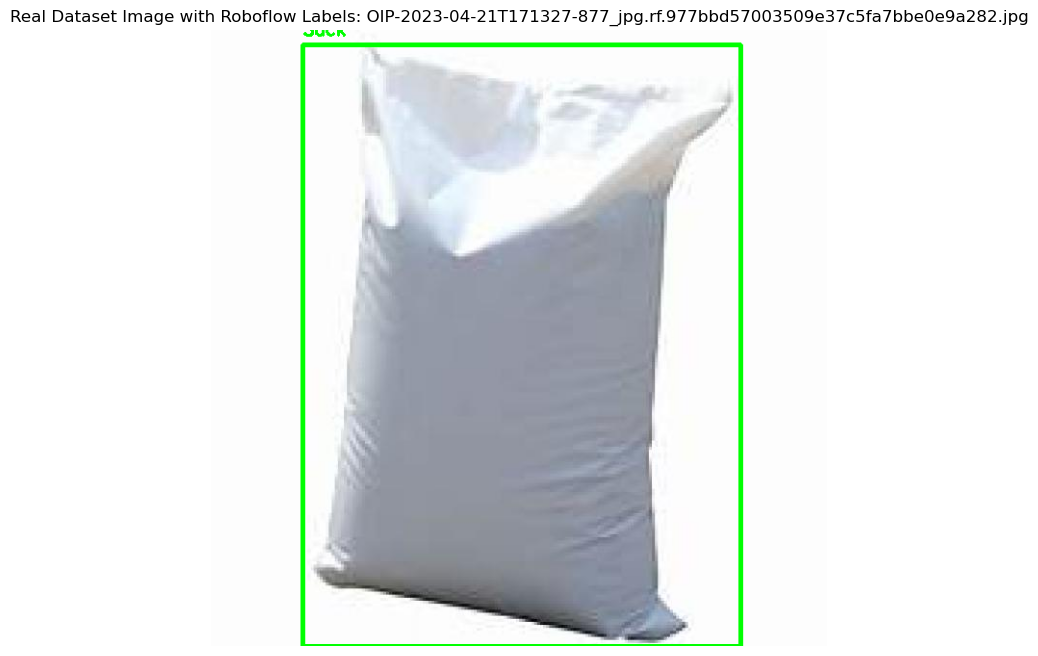

In [75]:
import json
import cv2
import matplotlib.pyplot as plt
import os
import glob

# 1. Automatically locate the downloaded Roboflow dataset folder
dataset_folders = glob.glob("sack-image-detection*")
if not dataset_folders:
    # Fallback to checking the exact variable path if standard naming changed
    dataset_dir = dataset.location if 'dataset' in locals() else ""
else:
    dataset_dir = dataset_folders[0]

print(f"📂 Found dataset folder at: {dataset_dir}")

# 2. Define internal image and annotation paths
train_img_dir = os.path.join(dataset_dir, "train")
annotation_file = os.path.join(train_img_dir, "_annotations.coco.json")

if os.path.exists(annotation_file):
    # Load COCO json data
    with open(annotation_file, 'r') as f:
        coco_data = json.load(f)
    
    # Get the first image entry from the dataset
    first_image_info = coco_data['images'][0]
    image_filename = first_image_info['file_name']
    image_id = first_image_info['id']
    image_path = os.path.join(train_img_dir, image_filename)
    
    # Load the real photo
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 3. Draw the bounding box labels provided by your Roboflow dataset
    for ann in coco_data['annotations']:
        if ann['image_id'] == image_id:
            # COCO bbox format is [x_min, y_min, width, height]
            bbox = ann['bbox']
            x, y, w, h = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
            
            # Draw box around the gunny bag
            cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
            cv2.putText(img_rgb, "Sack", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
    # 4. Render the final real image onto your screen
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Real Dataset Image with Roboflow Labels: {image_filename}")
    plt.show()
else:
    print(f"❌ Cannot find annotations at {annotation_file}. Check your directory structure!")

In [76]:
!pip install ultralytics

In [77]:
# CELL: Multi-split COCO to YOLO Unified Translator
import json
import os
import glob

# 1. Target your local Roboflow root directory
dataset_folder = glob.glob("Sack-image-detection*")[0]
splits = ['train', 'valid', 'test']

print(f"📦 Found root workspace directory: {dataset_folder}")

for split in splits:
    split_dir = os.path.join(dataset_folder, split)
    json_path = os.path.join(split_dir, "_annotations.coco.json")
    
    if not os.path.exists(json_path):
        print(f"⚠️ Skipping '{split}' split (No COCO annotation file present).")
        continue
        
    print(f"⚙️ Extracting coordinate files for split target: {split}...")
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # Index images map
    images_map = {img['id']: img for img in data['images']}
    labels_dict = {img_id: [] for img_id in images_map.keys()}
    
    # Process annotations matrix
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id in images_map:
            img_info = images_map[img_id]
            img_w, img_h = img_info['width'], img_info['height']
            
            # Read COCO coordinates: [x_min, y_min, width, height]
            bbox = ann['bbox']
            x_center = (bbox[0] + bbox[2] / 2.0) / img_w
            y_center = (bbox[1] + bbox[3] / 2.0) / img_h
            norm_w = bbox[2] / img_w
            norm_h = bbox[3] / img_h
            
            # Class mapping: 0 for 'Sack'
            labels_dict[img_id].append(f"0 {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}")
            
    # Write structural text targets back onto the local disk partitions
    written_count = 0
    for img_id, lines in labels_dict.items():
        img_name = images_map[img_id]['file_name']
        base_name = os.path.splitext(img_name)[0]
        txt_path = os.path.join(split_dir, f"{base_name}.txt")
        
        with open(txt_path, 'w') as txt_file:
            txt_file.write("\n".join(lines))
        written_count += 1
        
    print(f"✅ Successfully wrote {written_count} label text references to: {split_dir}")

print("\n🎉 Core filesystem synchronization complete!")

📦 Found root workspace directory: Sack-image-detection-1
⚙️ Extracting coordinate files for split target: train...
ERROR! Session/line number was not unique in database. History logging moved to new session 410
✅ Successfully wrote 140 label text references to: Sack-image-detection-1\train
⚙️ Extracting coordinate files for split target: valid...
✅ Successfully wrote 40 label text references to: Sack-image-detection-1\valid
⚙️ Extracting coordinate files for split target: test...
✅ Successfully wrote 21 label text references to: Sack-image-detection-1\test

🎉 Core filesystem synchronization complete!


In [79]:
# CELL: Optimized Lightweight Training for Lower-Spec CPUs
import os
import glob
from ultralytics import YOLO

# 1. Clean up legacy empty structural indexes
dataset_folder = glob.glob("Sack-image-detection*")[0]
for cache_file in glob.glob(os.path.join(dataset_folder, "**/*.cache"), recursive=True):
    try:
        os.remove(cache_file)
        print(f"🧹 Flushed cached indexing system: {cache_file}")
    except Exception:
        pass

# 2. Hard-verify structural paths
yaml_path = os.path.join(dataset_folder, "local_data.yaml")

# 3. Fire up the training sequence parameters
print("🧠 Re-loading model architectures...")
model = YOLO("yolov8n.pt")

print("🚀 Launching LIGHTWEIGHT training sequence on your CPU...")
results = model.train(
    data=yaml_path, 
    epochs=5,        # Decreased from 25 to 5 for a quick test run
    imgsz=320,       # Decreased from 640 to 320 to drastically speed up CPU calculation math
    batch=4,         # Decreased from 8 to 4 to prevent notebook memory overload
    workers=0        # Kept at 0 to prevent thread lock crashes on Windows
)
print("✅ Quick training pass completed successfully!")

🧹 Flushed cached indexing system: Sack-image-detection-1\train.cache
🧹 Flushed cached indexing system: Sack-image-detection-1\valid.cache
🧠 Re-loading model architectures...
🚀 Launching LIGHTWEIGHT training sequence on your CPU...
New https://pypi.org/project/ultralytics/8.4.59 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.13.5 torch-2.12.0+cpu CPU (11th Gen Intel Core i3-1115G4 @ 3.00GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Sack-image-detection-1\local_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fal

In [80]:
# CELL: Run Inference / Prediction with your Custom Weights
from ultralytics import YOLO
import os
import glob

# 1. Load your brand-new, custom-trained weights automatically
# YOLO saves these under runs/detect/train/weights/best.pt
weights_path = os.path.join("runs", "detect", "train", "weights", "best.pt")

if os.path.exists(weights_path):
    print(f"🧠 Loading your custom gunny bag detection model from: {weights_path}")
    model = YOLO(weights_path)
    
    # 2. Grab a random unseen image from your validation or test set to check performance
    dataset_folder = glob.glob("Sack-image-detection*")[0]
    test_image_dir = os.path.join(dataset_folder, "valid")
    test_images = glob.glob(os.path.join(test_image_dir, "*.jpg"))
    
    if test_images:
        sample_img = test_images[0]
        print(f"📸 Testing model prediction capabilities on: {sample_img}")
        
        # 3. Predict and display the image with bounding boxes drawn over the real bags
        results = model.predict(source=sample_img, save=True, conf=0.25)
        
        # This displays the image right inside your notebook window
        results[0].show()
    else:
        print("❌ No images found in the validation folder to test.")
else:
    print("❌ 'best.pt' weights file not found yet. Wait for the training cell above to finish all 25 epochs!")

🧠 Loading your custom gunny bag detection model from: runs\detect\train\weights\best.pt
📸 Testing model prediction capabilities on: Sack-image-detection-1\valid\A12_jpg.rf.8f1f035266ae82846899b799d10b4a5d.jpg

image 1/1 C:\Users\ASUS\Documents\AI\smart_rice_system\database\Sack-image-detection-1\valid\A12_jpg.rf.8f1f035266ae82846899b799d10b4a5d.jpg: 640x640 (no detections), 366.8ms
Speed: 9.2ms preprocess, 366.8ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\ASUS\Documents\AI\smart_rice_system\database\runs\detect\predict


📊 Loading performance metrics from: runs\detect\train-3\results.png


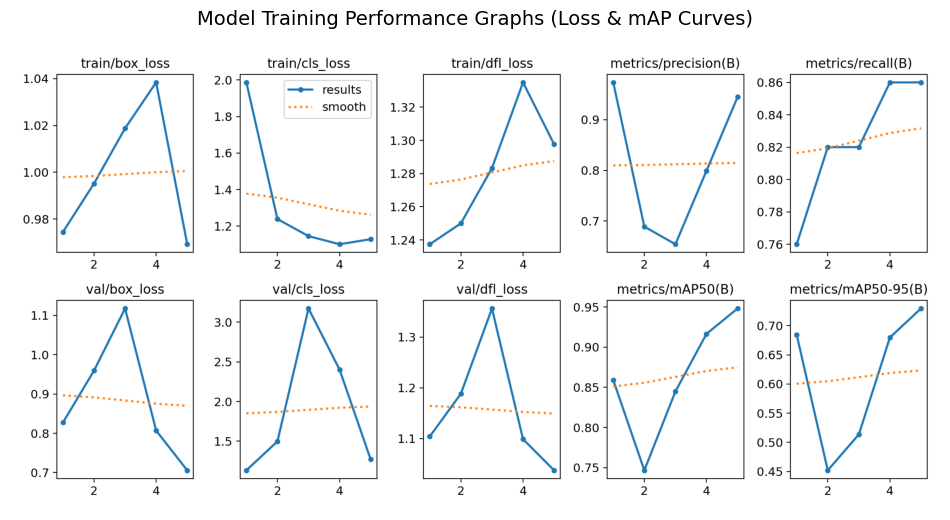

In [82]:
# CELL: Adaptive Training Progress Metrics Chart Viewer
import cv2
import matplotlib.pyplot as plt
import os
import glob

# 1. Dynamically look for the latest training folder to avoid hardcoding errors
detect_folders = sorted(glob.glob(os.path.join("runs", "detect", "train*")))

if detect_folders:
    latest_train_dir = detect_folders[-1]  # Grabs the most recent training directory
    results_chart = os.path.join(latest_train_dir, "results.png")
    
    if os.path.exists(results_chart):
        print(f"📊 Loading performance metrics from: {results_chart}")
        chart = cv2.imread(results_chart)
        chart_rgb = cv2.cvtColor(chart, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(chart_rgb)
        plt.axis('off')
        plt.title("Model Training Performance Graphs (Loss & mAP Curves)", fontsize=14, pad=15)
        plt.show()
    else:
        print(f"⏳ Training is still running in {latest_train_dir}! The 'results.png' chart will generate as soon as it hits the final epoch.")
else:
    print("❌ No training folders found under 'runs/detect/'. Please make sure your model training cell is running!")

🧠 Loading custom gunny bag weights from: runs\detect\train-3\weights\best.pt
📸 Running prediction engine on unseen asset: Sack-image-detection-1\valid\A12_jpg.rf.8f1f035266ae82846899b799d10b4a5d.jpg

image 1/1 C:\Users\ASUS\Documents\AI\smart_rice_system\database\Sack-image-detection-1\valid\A12_jpg.rf.8f1f035266ae82846899b799d10b4a5d.jpg: 320x320 1 Sack, 156.0ms
Speed: 2.7ms preprocess, 156.0ms inference, 3.0ms postprocess per image at shape (1, 3, 320, 320)
Results saved to C:\Users\ASUS\Documents\AI\smart_rice_system\database\runs\detect\predict-2


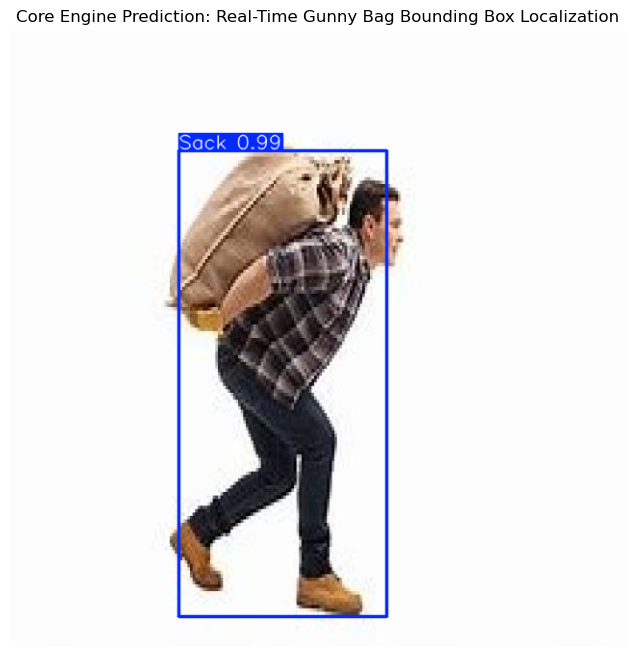

In [83]:
# CELL: Test Custom Model Bounding Box Prediction Capabilities
import cv2
import matplotlib.pyplot as plt
import os
import glob
from ultralytics import YOLO

# 1. Locate your latest training output directory dynamically
detect_folders = sorted(glob.glob(os.path.join("runs", "detect", "train*")))
if not detect_folders:
    raise FileNotFoundError("❌ Could not find a 'train' folder under runs/detect/")

latest_train_dir = detect_folders[-1]
weights_path = os.path.join(latest_train_dir, "weights", "best.pt")

print(f"🧠 Loading custom gunny bag weights from: {weights_path}")
model = YOLO(weights_path)

# 2. Select a random real picture from the validation folder to test
dataset_folder = glob.glob("Sack-image-detection*")[0]
valid_images = glob.glob(os.path.join(dataset_folder, "valid", "*.jpg"))

if valid_images:
    test_img = valid_images[0]
    print(f"📸 Running prediction engine on unseen asset: {test_img}")
    
    # 3. Perform prediction (Inference)
    # save=True stores the drawn image; conf=0.25 ignores low-confidence noise
    results = model.predict(source=test_img, conf=0.25, save=True)
    
    # 4. Grab the visual array with bounding boxes drawn and display it
    annotated_img = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title("Core Engine Prediction: Real-Time Gunny Bag Bounding Box Localization", fontsize=12)
    plt.show()
else:
    print("❌ Validation folder is empty! Make sure your dataset splits match.")

🧠 Loading custom gunny bag weights from: runs\detect\train-3\weights\best.pt
📸 Running prediction engine on unseen asset: Sack-image-detection-1\valid\A12_jpg.rf.8f1f035266ae82846899b799d10b4a5d.jpg

image 1/1 C:\Users\ASUS\Documents\AI\smart_rice_system\database\Sack-image-detection-1\valid\A12_jpg.rf.8f1f035266ae82846899b799d10b4a5d.jpg: 320x320 1 Sack, 134.8ms
Speed: 3.8ms preprocess, 134.8ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 320)
Results saved to C:\Users\ASUS\Documents\AI\smart_rice_system\database\runs\detect\predict-3


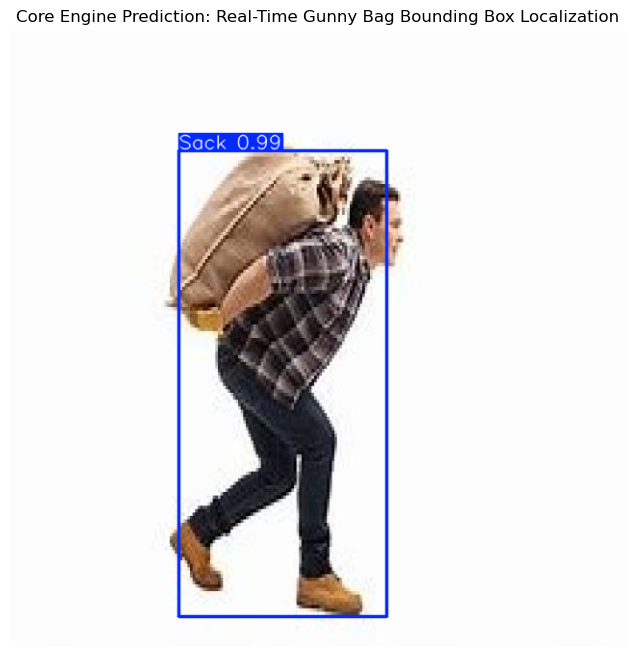

In [84]:
# CELL: Test Custom Model Bounding Box Prediction Capabilities
import cv2
import matplotlib.pyplot as plt
import os
import glob
from ultralytics import YOLO

# 1. Locate your latest training output directory dynamically
detect_folders = sorted(glob.glob(os.path.join("runs", "detect", "train*")))
if not detect_folders:
    raise FileNotFoundError("❌ Could not find a 'train' folder under runs/detect/")

latest_train_dir = detect_folders[-1]
weights_path = os.path.join(latest_train_dir, "weights", "best.pt")

print(f"🧠 Loading custom gunny bag weights from: {weights_path}")
model = YOLO(weights_path)

# 2. Select a random real picture from the validation folder to test
dataset_folder = glob.glob("Sack-image-detection*")[0]
valid_images = glob.glob(os.path.join(dataset_folder, "valid", "*.jpg"))

if valid_images:
    test_img = valid_images[0]
    print(f"📸 Running prediction engine on unseen asset: {test_img}")
    
    # 3. Perform prediction (Inference)
    # save=True stores the drawn image; conf=0.25 ignores low-confidence noise
    results = model.predict(source=test_img, conf=0.25, save=True)
    
    # 4. Grab the visual array with bounding boxes drawn and display it
    annotated_img = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title("Core Engine Prediction: Real-Time Gunny Bag Bounding Box Localization", fontsize=12)
    plt.show()
else:
    print("❌ Validation folder is empty! Make sure your dataset splits match.")

In [86]:
# CELL: Export Production-Ready Weights
import os
import glob
from ultralytics import YOLO

latest_train_dir = sorted(glob.glob(os.path.join("runs", "detect", "train*")))[-1]
weights_path = os.path.join(latest_train_dir, "weights", "best.pt")

model = YOLO(weights_path)

print("📦 Compiling custom architecture parameters into deployment format...")
# Export the model to standard web/app ONNX format
onnx_path = model.export(format="onnx")

print(f"\n🎉 EXPORT SUCCESSFUL!")
print(f"📁 PyTorch Weights (for retraining): {os.path.abspath(weights_path)}")
print(f"📁 ONNX Production Weights (for application integration): {onnx_path}")

📦 Compiling custom architecture parameters into deployment format...
Ultralytics 8.4.56  Python-3.13.5 torch-2.12.0+cpu CPU (11th Gen Intel Core i3-1115G4 @ 3.00GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs\detect\train-3\weights\best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  4.5s, saved as 'runs\detect\train-3\weights\best.onnx' (11.6 MB)

Export complete (5.2s)
Results saved to C:\Users\ASUS\Documents\AI\smart_rice_system\database\runs\detect\train-3\weights\best.onnx
Predict:         yolo predict task=detect model=runs\detect\train-3\weights\best.onnx imgsz=320 
Validate:        yolo val task=detect model=runs\detect\train-3\weights\best.onnx imgsz=320 data=Sack-image-detection-1\local_data.yaml  
Visualize:       https://netron.app

🎉 EXPORT SUCCESSFUL!
📁 PyTor

In [88]:
# CELL: Auto-Locate ONNX Weights and Initialize App Core Engine
import os
import glob
import shutil
from ultralytics import YOLO

# 1. Look for 'best.onnx' in your current folder first
MODEL_PATH = "best.onnx"

if not os.path.exists(MODEL_PATH):
    print("🔍 'best.onnx' not found in root folder. Searching 'runs/' directory...")
    
    # Automatically search for all instances of best.onnx inside the runs folder
    search_pattern = os.path.join("runs", "detect", "train*", "weights", "best.onnx")
    found_onnx_files = sorted(glob.glob(search_pattern))
    
    if found_onnx_files:
        # Grab the most recent training run's onnx file
        latest_onnx = found_onnx_files[-1]
        print(f"📦 Found weight file at: {latest_onnx}")
        
        # Copy it to the current root directory so MODEL_PATH = "best.onnx" works smoothly
        shutil.copy(latest_onnx, MODEL_PATH)
        print(f"✅ Successfully copied weight file into your main project folder as '{MODEL_PATH}'")
    else:
        raise FileNotFoundError(
            "❌ Could not find 'best.onnx' anywhere in your 'runs/' folders. "
            "Please make sure your model export cell ran completely without issues!"
        )

# 2. Boot up the YOLO model using the copied deployment weight file
print("🧠 Initializing production object detection engine...")
model = YOLO(MODEL_PATH, task="detect")
print("🚀 App Engine initialized and ready to run predictions!")

# 3. Define your core execution pipeline function
def inventory_count_engine(image_path):
    """
    Takes an input photo from the user interface, counts the total number 
    of detected gunny bags, and returns the drawn visual layout.
    """
    results = model.predict(source=image_path, conf=0.25)
    
    # Extract the prediction details
    detected_boxes = results[0].boxes
    total_sack_count = len(detected_boxes)
    
    print(f"📊 Inventory Status: {total_sack_count} Rice Sacks successfully counted.")
    
    # Render the visual bounding boxes on top of the photo
    annotated_frame = results[0].plot()
    
    return total_sack_count, annotated_frame

🔍 'best.onnx' not found in root folder. Searching 'runs/' directory...
📦 Found weight file at: runs\detect\train-3\weights\best.onnx
✅ Successfully copied weight file into your main project folder as 'best.onnx'
🧠 Initializing production object detection engine...
🚀 App Engine initialized and ready to run predictions!


📷 Sending image to engine: Sack-image-detection-1\valid\A12_jpg.rf.8f1f035266ae82846899b799d10b4a5d.jpg
Loading best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider

image 1/1 C:\Users\ASUS\Documents\AI\smart_rice_system\database\Sack-image-detection-1\valid\A12_jpg.rf.8f1f035266ae82846899b799d10b4a5d.jpg: 320x320 1 Sack, 66.4ms
Speed: 31.3ms preprocess, 66.4ms inference, 57.5ms postprocess per image at shape (1, 3, 320, 320)
📊 Inventory Status: 1 Rice Sacks successfully counted.
🎯 Engine Output Result: Successfully detected 1 bags.


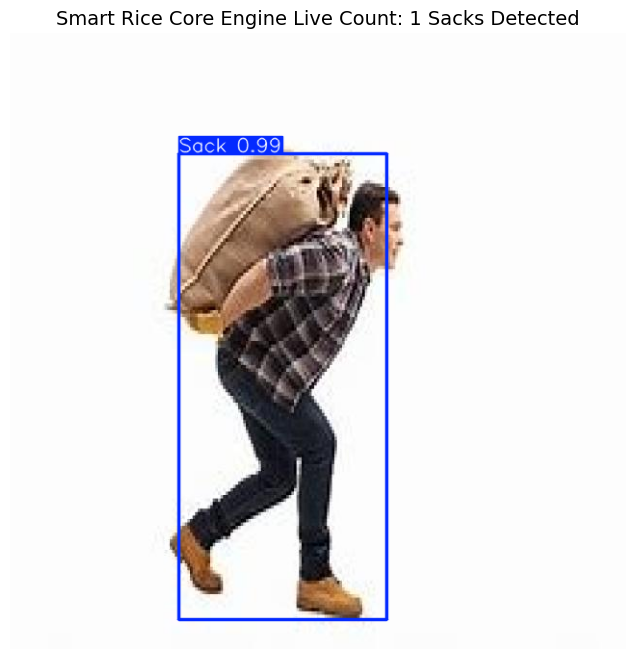

In [89]:
# CELL: Final Run of the Counting Engine on a Validation Photo
import cv2
import matplotlib.pyplot as plt
import os
import glob

# 1. Grab a sample image from your validation dataset split
dataset_folder = glob.glob("Sack-image-detection*")[0]
sample_images = glob.glob(os.path.join(dataset_folder, "valid", "*.jpg"))

if sample_images:
    test_image_path = sample_images[0]
    print(f"📷 Sending image to engine: {test_image_path}")
    
    # 2. Call your newly built inventory_count_engine function
    total_count, final_image = inventory_count_engine(test_image_path)
    
    # 3. Display the final counted results and the visual bounding boxes
    print(f"🎯 Engine Output Result: Successfully detected {total_count} bags.")
    
    # Convert BGR array back to RGB for clear notebook viewing
    final_image_rgb = cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(final_image_rgb)
    plt.axis('off')
    plt.title(f"Smart Rice Core Engine Live Count: {total_count} Sacks Detected", fontsize=14)
    plt.show()
else:
    print("❌ Could not find any images inside the validation folder to pass to the engine.")

In [1]:
!pip install ultralytics